This notebook performs cell phenotyping analysis, similar to the NSCLC Cancer Cell paper

In [8]:
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import pickle as pkl
import skimage
import yaml
from typing import Union, Optional, Type, Tuple, List, Dict
import sys
from skimage.color import label2rgb
import json
# import nrrd

import pandas as pd
import seaborn as sns
# Project Root
# used for searching packages and functions
# TODO: enter your project root dir here
ROOT_DIR = '/project/Xie_Lab/zgu/xiao_multiplex/multiTAP/image_cytof'

sys.path.append(ROOT_DIR)
sys.path.append(os.path.join(ROOT_DIR, 'image_cytof'))
from cytof.hyperion_preprocess import cytof_read_data_roi
from cytof.utils import save_multi_channel_img, check_feature_distribution
from cytof.classes import CytofImageTiff
from cytof.classes import CytofCohort


/project/Xie_Lab/zgu/conda_stuff/envs/cytof-shared/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
SAVED_GROUPS = [86, 87, 88, 175, 176, 178]
BASE_CSV_DIR = "/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work"
accuml_type = 'sum'
cell_suffix = f"cell_{accuml_type}"

# pt id and ROI id mapping
roi_pt_id_mapping = pd.read_csv('/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/roi_pt_id_mapping.csv')


In [10]:
bin_df_list = list()

# merge the binary dfs
for prefix in SAVED_GROUPS:
    csv_path = os.path.join(BASE_CSV_DIR, f"nsclc_save_group{prefix}", f"nsclc_save_group{prefix}_binary_expr_df_{accuml_type}.csv")
    df = pd.read_csv(csv_path)
    bin_df_list.append(df)

combined_binary_df = pd.concat(bin_df_list, axis=0, ignore_index=True)
# combined_spatial_df['roi_mappable'] = combined_spatial_df['ROI_ID'].apply(extract_roi_id)
combined_binary_df

,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,anti-Hu_1950((2832))Yb173-Yb173_cell_sum,CCL21 6_2177((2889))Yb174-Yb174_cell_sum,panCyto_234((2745))Lu175-Lu175_cell_sum,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1
1,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1
3,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3950215,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15
3950216,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15
3950217,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15
3950218,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15


In [11]:
# len(np.unique(combined_binary_df['pt_id']))
tumor_marker = f"panCyto_234((2745))Lu175-Lu175_{cell_suffix}"
# first find the tumor cells by panCK
tumor_cells = combined_binary_df[combined_binary_df[tumor_marker]].reset_index(drop=True)
non_tumor_cells = combined_binary_df[~combined_binary_df[tumor_marker]].reset_index(drop=True)
print(len(tumor_cells), "tumors cells identified")



1040149 tumors cells identified


In [12]:
# remove cells with both CD3 and CD20 positive
cd3_marker = f"CD3_1841((3363))Sm152-Sm152_{cell_suffix}"
cd20_marker = f"CD20_36((3369))Sm149-Sm149_{cell_suffix}"
non_tumor_cleaned = non_tumor_cells[~(non_tumor_cells[cd3_marker] & non_tumor_cells[cd20_marker])]
non_tumor_cleaned

,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,anti-Hu_1950((2832))Yb173-Yb173_cell_sum,CCL21 6_2177((2889))Yb174-Yb174_cell_sum,panCyto_234((2745))Lu175-Lu175_cell_sum,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2910066,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15
2910067,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15
2910068,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15
2910069,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15


In [13]:
print(len(non_tumor_cleaned[non_tumor_cleaned[cd3_marker]]))
print(len(non_tumor_cleaned[non_tumor_cleaned[cd20_marker]]))

71774
76040


In [14]:
non_tumor_cleaned["final_cell_type"] = np.nan

# assign CD4 Treg (CD3+/CD4+/FOXP3+)
cd4_marker = f"CD4_2293((3000))Yb171-Yb171_{cell_suffix}"
foxp3_marker = f"FOXP3_115((2911))Dy163-Dy163_{cell_suffix}"

cd4_t_reg_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd4_marker] & non_tumor_cleaned[foxp3_marker]
non_tumor_cleaned.loc[cd4_t_reg_index, "final_cell_type"] = "CD4 Treg"
print(np.sum(cd4_t_reg_index), "CD4 T reg identified")

# assign IDO positive subsets
ido_marker = f"Indolea_2281((3014))Eu151-Eu151_{cell_suffix}"
ido_cd4_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd4_marker] & non_tumor_cleaned[ido_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[ido_cd4_index, "final_cell_type"] = "IDO_CD4"
print(np.sum(ido_cd4_index), "IDO_CD4 identified")

cd8_marker = f"CD8a_1718((2991))Er166-Er166_{cell_suffix}"
ido_cd8_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd8_marker] & non_tumor_cleaned[ido_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[ido_cd8_index, "final_cell_type"] = "IDO_CD8"
print(np.sum(ido_cd8_index), "IDO_CD8 identified")

# assign proliferation (Ki-67) subsets
ki67_marker = f"Ki-67_142((3418))Pt194-Pt194_{cell_suffix}"
ki67_cd4_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd4_marker] & non_tumor_cleaned[ki67_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[ki67_cd4_index, "final_cell_type"] = "Ki67_CD4"
print(np.sum(ki67_cd4_index), "Ki67 CD4 identified")

ki67_cd8_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd8_marker] & non_tumor_cleaned[ki67_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[ki67_cd8_index, "final_cell_type"] = "Ki67_CD8"
print(np.sum(ki67_cd8_index), "Ki67 CD8 identified")

# assign TCF1/7 subsets
# TCF7 gene also known as TCF-1 
tcf7_marker = f"TCF1TCF_2221((3415))Gd160-Gd160_{cell_suffix}"
tcf7_cd4_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd4_marker] & non_tumor_cleaned[tcf7_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[tcf7_cd4_index, "final_cell_type"] = "TCF1/7 CD4"
print(np.sum(tcf7_cd4_index), "TCF1/7 CD4 identified")

tcf7_cd8_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd8_marker] & non_tumor_cleaned[tcf7_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[tcf7_cd8_index, "final_cell_type"] = "TCF1/7 CD8"
print(np.sum(tcf7_cd8_index), "TCF1/7 CD8 identified")

# assign PD-1 subsets
pd1_marker = f"CD279(P_1743((3414))Gd155-Gd155_{cell_suffix}"
pd1_cd4_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd8_marker] & non_tumor_cleaned[pd1_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[pd1_cd4_index, "final_cell_type"] = "PD1 CD4"
print(np.sum(pd1_cd4_index), "PD1 CD4 identified")

# assign general CD4 and CD8
cd4_only_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd4_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[cd4_only_index, "final_cell_type"] = "CD4"
print(np.sum(cd4_only_index), "CD4 general identified")

cd8_only_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd8_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[cd8_only_index, "final_cell_type"] = "CD8"
print(np.sum(cd8_only_index), "CD8 general identified")

non_tumor_cleaned

2256 CD4 T reg identified


/tmp/ipykernel_460591/3436617015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_tumor_cleaned["final_cell_type"] = np.nan


305 IDO_CD4 identified
1598 IDO_CD8 identified
572 Ki67 CD4 identified
2562 Ki67 CD8 identified
89 TCF1/7 CD4 identified
681 TCF1/7 CD8 identified
220 PD1 CD4 identified
907 CD4 general identified
25486 CD8 general identified


,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,CCL21 6_2177((2889))Yb174-Yb174_cell_sum,panCyto_234((2745))Lu175-Lu175_cell_sum,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id,final_cell_type
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2910066,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN
2910067,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN
2910068,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN
2910069,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN


In [15]:
# above assignments for T cells only
# allow assignment only in np.nan, so by defn it excludes T cells
hla_marker = f"HLA-DR_1849((3362))Nd143-Nd143_{cell_suffix}"
cd68_marker = f"CD68_77((3413))Nd150-Nd150_{cell_suffix}"
myeloid_index = non_tumor_cleaned[hla_marker] & non_tumor_cleaned[cd68_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[myeloid_index, "final_cell_type"] = "myeloid"
print(np.sum(myeloid_index), "myeloid cells identified")

# assign neutrophils
mpo_marker = f"Myelope_276((2996))Y89-Y89_{cell_suffix}"
mmp9_marker = f"MMP9_2241((2912))Gd158-Gd158_{cell_suffix}"
neutrophils_index = non_tumor_cleaned[mpo_marker] & non_tumor_cleaned[mmp9_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[neutrophils_index, "final_cell_type"] = "neutrophils"
print(np.sum(neutrophils_index), "neutrophils identified")

# assign B cells
b_cell_index = non_tumor_cleaned[cd20_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[b_cell_index, "final_cell_type"] = "B cells"
print(np.sum(b_cell_index), "B cells identified")

non_tumor_cleaned

60147 myeloid cells identified
31012 neutrophils identified
72278 B cells identified


,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,CCL21 6_2177((2889))Yb174-Yb174_cell_sum,panCyto_234((2745))Lu175-Lu175_cell_sum,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id,final_cell_type
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2910066,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN
2910067,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN
2910068,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN
2910069,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN


In [16]:
# subset vessel cells
# first find lymphatic endothelial
lyve_marker = f"LYVE-1_1982((2881))Er168-Er168_{cell_suffix}"
ccl21_marker = f"CCL21 6_2177((2889))Yb174-Yb174_{cell_suffix}"
lymphatic_index = non_tumor_cleaned[lyve_marker] & non_tumor_cleaned[ccl21_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[lymphatic_index, "final_cell_type"] = "lymphatic endothelial"
print(np.sum(lymphatic_index), "lymphatic cells identified")

# then overwrite lymphatic with HEV if PNAd+
pnad_marker = f"PNAd_1981((3323))Ho165-Ho165_{cell_suffix}"
hev_cells_index = non_tumor_cleaned[pnad_marker] & lymphatic_index
non_tumor_cleaned.loc[hev_cells_index, "final_cell_type"] = "high endothelial venules (HEV)"
print(np.sum(hev_cells_index), "HEVs identified")

# get general endothelial cells (CD146+/CD31+/vWF+/CCL21-)
cd146_marker = f"CD146_22((3259))Nd144-Nd144_{cell_suffix}"
cd31_vwf_marker = f"CD31_1859((3370))Yb172-Yb172_{cell_suffix}"
endothelial_index = non_tumor_cleaned[cd146_marker] & non_tumor_cleaned[cd31_vwf_marker] & (~non_tumor_cleaned[ccl21_marker]) & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[endothelial_index, "final_cell_type"] = "endothelial"
print(np.sum(endothelial_index), "endothelial cells identified")

non_tumor_cleaned

3135 lymphatic cells identified
186 HEVs identified
35700 endothelial cells identified


,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,CCL21 6_2177((2889))Yb174-Yb174_cell_sum,panCyto_234((2745))Lu175-Lu175_cell_sum,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id,final_cell_type
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2910066,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN
2910067,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN
2910068,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN
2910069,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN


In [17]:
# # for comparision of 2 mCAF defn
# unassigned_index = non_tumor_cleaned['final_cell_type'].isna()

# # ablation on mCAF
# fap_marker = f"fap_323((3412))Nd142-Nd142_{cell_suffix}"
# mmp11_marker = f"MMP11_2925((3364))Sm154-Sm154_{cell_suffix}"
# collagen_marker = f"Collage_1360((2568))Sm147-Sm147_{cell_suffix}"
# sma_marker = f"SMA_174((3277))In115-In115_{cell_suffix}"

# # 1st defn
# mcaf_index1 = non_tumor_cleaned[fap_marker] & non_tumor_cleaned[mmp11_marker] & non_tumor_cleaned[collagen_marker] & unassigned_index
# # non_tumor_cleaned.loc[mcaf_index, "final_cell_type"] = "mCAF"
# print(np.sum(mcaf_index1), "mCAF identified")

# # 2nd defn
# mcaf_index2 = non_tumor_cleaned[sma_marker] & non_tumor_cleaned[mmp11_marker] & non_tumor_cleaned[collagen_marker] & unassigned_index
# # non_tumor_cleaned.loc[mcaf_index, "final_cell_type"] = "mCAF"
# print(np.sum(mcaf_index2), "mCAF identified")

# mcaf_index3 = non_tumor_cleaned[sma_marker] & non_tumor_cleaned[fap_marker] & non_tumor_cleaned[mmp11_marker] & non_tumor_cleaned[collagen_marker] & unassigned_index
# # non_tumor_cleaned.loc[mcaf_index, "final_cell_type"] = "mCAF"
# print(np.sum(mcaf_index3), "mCAF identified")

In [18]:
# check cell assignments so far
temp = non_tumor_cleaned[~non_tumor_cleaned['final_cell_type'].isna()]
print(np.unique(temp['final_cell_type'], return_counts=True))

# CAF assignments
# mCAF
fap_marker = f"fap_323((3412))Nd142-Nd142_{cell_suffix}"
mmp11_marker = f"MMP11_2925((3364))Sm154-Sm154_{cell_suffix}"
collagen_marker = f"Collage_1360((2568))Sm147-Sm147_{cell_suffix}"
sma_marker = f"SMA_174((3277))In115-In115_{cell_suffix}"

mcaf_index = non_tumor_cleaned[sma_marker] & non_tumor_cleaned[mmp11_marker] & non_tumor_cleaned[collagen_marker] & (non_tumor_cleaned['final_cell_type'].isna())
# mcaf_index = non_tumor_cleaned[fap_marker] & non_tumor_cleaned[mmp11_marker] & non_tumor_cleaned[collagen_marker] & (non_tumor_cleaned['final_cell_type'].isna())

non_tumor_cleaned.loc[mcaf_index, "final_cell_type"] = "mCAF"
print(np.sum(mcaf_index), "mCAF identified")

# iCAF
cd34_marker = f"CD34_2254((3337))Er170-Er170_{cell_suffix}"
cd248_marker = f"CD248 E_2178((2830))Er167-Er167_{cell_suffix}"
icaf_index = non_tumor_cleaned[cd34_marker] & non_tumor_cleaned[cd248_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[icaf_index, "final_cell_type"] = "iCAF"
print(np.sum(icaf_index), "iCAF identified")

# tCAF
cd10_marker = f"CD10_2546((3029))Dy161-Dy161_{cell_suffix}"
cd73_marker = f"CD73_2193((3319))Gd156-Gd156_{cell_suffix}"
tcaf_index = non_tumor_cleaned[cd10_marker] & non_tumor_cleaned[cd73_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[tcaf_index, "final_cell_type"] = "tCAF"
print(np.sum(tcaf_index), "tCAF identified")

# hypoxic CAF
caix_marker = f"Carboni_2443((2757))Nd146-Nd146_{cell_suffix}"
hypoxic_caf_index = non_tumor_cells[caix_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[hypoxic_caf_index, "final_cell_type"] = "hypoxic CAF"
print(np.sum(hypoxic_caf_index), "hypoxic CAF identified")

# hypoxic tCAF
# reassign classified hypoxic CAF to hypoxic tCAF if CD10+
hypoxic_tcaf_index = non_tumor_cells[cd10_marker] & hypoxic_caf_index
non_tumor_cleaned.loc[hypoxic_tcaf_index, "final_cell_type"] = "hypoxic tCAF"
print(np.sum(hypoxic_tcaf_index), "hypoxic tCAF identified")

#ifnCAF
ifn_caf_index = non_tumor_cells[ido_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[ifn_caf_index, "final_cell_type"] = "IFN CAF"
print(np.sum(ifn_caf_index), "IFN CAF identified")

# vCAF
vcaf_index = non_tumor_cells[cd146_marker] & (~non_tumor_cells[cd34_marker]) & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[vcaf_index, "final_cell_type"] = "vCAF"
print(np.sum(vcaf_index), "vCAF identified")

# dCAF
dcaf_index = non_tumor_cells[ki67_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[dcaf_index, "final_cell_type"] = "dCAF"
print(np.sum(dcaf_index), "dCAF identified")

# PDPN CAF
pdpn_marker = f"Podopla_1463((2619))Eu153-Eu153_{cell_suffix}"
pdpn_caf_index = non_tumor_cleaned[pdpn_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[pdpn_caf_index, "final_cell_type"] = "PDPN CAF"
print(np.sum(pdpn_caf_index), "PDPN CAF identified")

# SMA CAF
sma_caf_index = non_tumor_cleaned[sma_marker] & (~non_tumor_cleaned[fap_marker]) & (~non_tumor_cleaned[mmp11_marker]) & (~non_tumor_cleaned[collagen_marker]) & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[sma_caf_index, "final_cell_type"] = "SMA CAF"
print(np.sum(sma_caf_index), "SMA CAF identified")

# collagen CAF
collagen_caf_index = non_tumor_cleaned[collagen_marker] & (~non_tumor_cleaned[mmp11_marker]) & (~non_tumor_cleaned[sma_marker])  & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[collagen_caf_index, "final_cell_type"] = "Collagen CAF"
print(np.sum(collagen_caf_index), "Collagen CAF identified")



non_tumor_cleaned

(array(['B cells', 'CD4', 'CD4 Treg', 'CD8', 'IDO_CD4', 'IDO_CD8',
       'Ki67_CD4', 'Ki67_CD8', 'PD1 CD4', 'TCF1/7 CD4', 'TCF1/7 CD8',
       'endothelial', 'high endothelial venules (HEV)',
       'lymphatic endothelial', 'myeloid', 'neutrophils'], dtype=object), array([72278,   907,  2256, 25486,   305,  1598,   572,  2562,   220,
          89,   681, 35700,   186,  2949, 60147, 31012]))
12860 mCAF identified
11466 iCAF identified
8530 tCAF identified
70477 hypoxic CAF identified
7457 hypoxic tCAF identified
32185 IFN CAF identified
31862 vCAF identified
62842 dCAF identified
29612 PDPN CAF identified
156004 SMA CAF identified
143197 Collagen CAF identified


,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,CCL21 6_2177((2889))Yb174-Yb174_cell_sum,panCyto_234((2745))Lu175-Lu175_cell_sum,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id,final_cell_type
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,NaN
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,SMA CAF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2910066,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN
2910067,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN
2910068,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN
2910069,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,NaN


# assign pt metacluster 

In [19]:
pt_cell_type_long = non_tumor_cleaned[["pt_id", "roi_id", "final_cell_type"]]
pt_cell_type_long["final_cell_type"] = pt_cell_type_long["final_cell_type"].fillna(value="undefined")
pt_cell_type_long

/tmp/ipykernel_460591/970451086.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pt_cell_type_long["final_cell_type"] = pt_cell_type_long["final_cell_type"].fillna(value="undefined")


,pt_id,roi_id,final_cell_type
0,86_1,NSCLC_ALL_86_A_A1_1,undefined
1,86_1,NSCLC_ALL_86_A_A1_1,undefined
2,86_1,NSCLC_ALL_86_A_A1_1,undefined
3,86_1,NSCLC_ALL_86_A_A1_1,undefined
4,86_1,NSCLC_ALL_86_A_A1_1,SMA CAF
...,...,...,...
2910066,178_571,NSCLC_ALL_178_C_C_4_15,undefined
2910067,178_571,NSCLC_ALL_178_C_C_4_15,undefined
2910068,178_571,NSCLC_ALL_178_C_C_4_15,undefined
2910069,178_571,NSCLC_ALL_178_C_C_4_15,undefined


In [20]:
pt_cell_type_wide = (
    pt_cell_type_long
    .groupby(["pt_id", "roi_id", "final_cell_type"])
    .size()  # count rows per group
    .unstack(fill_value=0)  # pivot cell types into columns
    .reset_index()
)

pt_cell_type_wide


final_cell_type,pt_id,roi_id,B cells,CD4,CD4 Treg,CD8,Collagen CAF,IDO_CD4,IDO_CD8,IFN CAF,...,hypoxic CAF,hypoxic tCAF,iCAF,lymphatic endothelial,mCAF,myeloid,neutrophils,tCAF,undefined,vCAF
0,175_1,NSCLC_ALL_175_A_A1_1,13,0,0,0,3,0,0,3,...,79,0,1,0,4,4,11,3,427,0
1,175_1,NSCLC_ALL_175_A_A2_1,13,0,0,1,1,0,0,2,...,27,0,1,0,7,17,4,1,455,7
2,175_10,NSCLC_ALL_175_A_A3_3,3,0,5,5,7,0,0,0,...,1,0,39,0,45,6,27,30,358,33
3,175_10,NSCLC_ALL_175_A_A4_3,0,2,9,14,2,0,1,9,...,0,0,0,0,2,1,10,2,379,12
4,175_100,NSCLC_ALL_175_B_B7_8,5,0,1,9,1,0,1,16,...,17,3,0,1,3,12,84,1,466,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1947,88_536,NSCLC_ALL_88_C_C6_13,28,0,0,0,7,0,0,1,...,0,0,0,0,0,10,16,13,1138,154
1948,88_537,NSCLC_ALL_88_C_C7_13,10,0,0,0,0,0,0,4,...,0,0,51,1,0,21,7,51,1658,2
1949,88_537,NSCLC_ALL_88_C_C8_13,2,0,0,0,2,0,0,1,...,0,0,2,16,3,21,17,10,1196,6
1950,88_538,NSCLC_ALL_88_C_C1_14,0,0,0,0,101,0,0,0,...,51,9,0,0,0,3,12,0,666,64


In [21]:
# define CAF columns
caf_cols = ["pt_id", "mCAF", "iCAF", "tCAF", "hypoxic CAF", "hypoxic tCAF", "IFN CAF", "vCAF", "dCAF", "PDPN CAF", "Collagen CAF", "SMA CAF"]
pt_CAF_only_wide = pt_cell_type_wide[caf_cols]

pt_CAF_only_wide["CAF_total"] = pt_CAF_only_wide[caf_cols].sum(axis=1)
# pt_CAF_only_wide = pt_CAF_only_wide[pt_CAF_only_wide["CAF_total"]>20].reset_index(drop=True)

# pt_caf_props
# # add within pt counts
pt_caf_summary = (
    pt_CAF_only_wide
    .groupby("pt_id")[caf_cols].sum()  # sum CAF counts across ROIs
    .assign(CAF_total=lambda x: x.sum(axis=1))  # total CAFs
    .reset_index()
)

# some pt have very few CAF values, remove them
pt_caf_counts = pt_caf_summary[pt_caf_summary['CAF_total']>20].reset_index(drop=True)
pt_caf_counts = pt_caf_counts.drop(columns="CAF_total")
pt_caf_counts = pt_caf_counts.set_index(keys='pt_id')
pt_caf_counts

/tmp/ipykernel_460591/2651967390.py:5: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  pt_CAF_only_wide["CAF_total"] = pt_CAF_only_wide[caf_cols].sum(axis=1)
/tmp/ipykernel_460591/2651967390.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pt_CAF_only_wide["CAF_total"] = pt_CAF_only_wide[caf_cols].sum(axis=1)
/tmp/ipykernel_460591/2651967390.py:11: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function

final_cell_type,mCAF,iCAF,tCAF,hypoxic CAF,hypoxic tCAF,IFN CAF,vCAF,dCAF,PDPN CAF,Collagen CAF,SMA CAF
pt_id,,,,,,,,,,,
175_1,11,2,4,106,0,5,7,20,5,4,997
175_10,47,39,32,1,0,9,45,10,24,9,225
175_100,23,0,3,18,3,42,34,2,2,243,113
175_101,26,29,12,13,2,124,9,47,0,56,85
175_102,1,57,20,1,0,63,68,168,4,174,72
...,...,...,...,...,...,...,...,...,...,...,...
88_534,9,1,1,2,0,4,41,34,9,72,59
88_535,0,0,0,5,0,0,8,1,10,1,6
88_536,18,0,13,0,0,1,174,20,1,79,48


In [22]:
# proportions per patient
pt_caf_props = pt_caf_counts.div(pt_caf_counts.sum(axis=1), axis=0)
pt_caf_props

final_cell_type,mCAF,iCAF,tCAF,hypoxic CAF,hypoxic tCAF,IFN CAF,vCAF,dCAF,PDPN CAF,Collagen CAF,SMA CAF
pt_id,,,,,,,,,,,
175_1,0.009475,0.001723,0.003445,0.091301,0.000000,0.004307,0.006029,0.017227,0.004307,0.003445,0.858742
175_10,0.106576,0.088435,0.072562,0.002268,0.000000,0.020408,0.102041,0.022676,0.054422,0.020408,0.510204
175_100,0.047619,0.000000,0.006211,0.037267,0.006211,0.086957,0.070393,0.004141,0.004141,0.503106,0.233954
175_101,0.064516,0.071960,0.029777,0.032258,0.004963,0.307692,0.022333,0.116625,0.000000,0.138958,0.210918
175_102,0.001592,0.090764,0.031847,0.001592,0.000000,0.100318,0.108280,0.267516,0.006369,0.277070,0.114650
...,...,...,...,...,...,...,...,...,...,...,...
88_534,0.038793,0.004310,0.004310,0.008621,0.000000,0.017241,0.176724,0.146552,0.038793,0.310345,0.254310
88_535,0.000000,0.000000,0.000000,0.161290,0.000000,0.000000,0.258065,0.032258,0.322581,0.032258,0.193548
88_536,0.050847,0.000000,0.036723,0.000000,0.000000,0.002825,0.491525,0.056497,0.002825,0.223164,0.135593


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

caf_cols_plotting = ["mCAF", "iCAF", "tCAF", "hypoxic CAF", "hypoxic tCAF", "IFN CAF", "vCAF", "dCAF", "PDPN CAF", "Collagen CAF", "SMA CAF"]

# --- Clustering patients on proportions ---
Z = linkage(pt_caf_props, method="ward")         # hierarchical clustering
clusters = fcluster(Z, t=4, criterion="maxclust")  # assign 4 meta-clusters

In [24]:

# --- Reorder patients by clustering ---
dendro = dendrogram(Z, labels=pt_caf_props.index, no_plot=True)
ordered_idx = dendro["ivl"]

print(ordered_idx)

# reorder everything
pt_caf_props_ordered = pt_caf_props.loc[ordered_idx]
pt_caf_counts_oredered = pt_caf_counts.loc[ordered_idx]
pt_cluster_ordered = pd.Series(clusters, index=pt_caf_props.index).loc[ordered_idx]

# map clusters to colors
cluster_palette = {1:"red", 2:"blue", 3:"green", 4:"purple"}
cluster_colors = pd.Series(clusters, index=pt_caf_props.index).map(cluster_palette)
cluster_colors = cluster_colors.loc[ordered_idx]
cluster_colors

['176_306', '88_443', '175_8', '178_490', '175_174', '87_301', '87_341', '87_346', '87_281', '87_314', '87_183', '176_278', '176_368', '176_219', '86_51', '175_119', '88_405', '87_316', '175_88', '87_257', '176_283', '87_176', '175_110', '87_185', '175_109', '176_235', '176_272', '87_221', '87_318', '176_249', '87_233', '176_341', '176_250', '176_342', '87_235', '86_101', '87_249', '175_12', '176_357', '87_179', '176_241', '176_304', '176_203', '87_304', '88_421', '178_467', '175_148', '175_103', '175_77', '87_299', '175_66', '176_360', '88_387', '178_553', '88_466', '87_343', '175_95', '87_275', '178_505', '176_232', '178_567', '176_207', '88_393', '87_262', '87_311', '86_142', '87_240', '176_236', '87_182', '175_108', '175_40', '88_485', '175_45', '178_483', '86_154', '88_493', '86_18', '175_79', '176_352', '88_487', '175_2', '86_158', '86_83', '88_460', '175_175', '176_367', '86_9', '87_331', '175_26', '88_494', '178_387', '178_518', '176_298', '175_39', '88_530', '176_345', '176_26

pt_id
176_306       red
88_443        red
175_8         red
178_490       red
175_174       red
            ...  
87_219     purple
175_93     purple
87_247     purple
178_521    purple
87_195     purple
Length: 1053, dtype: object

In [25]:
pt_caf_props_ordered

final_cell_type,mCAF,iCAF,tCAF,hypoxic CAF,hypoxic tCAF,IFN CAF,vCAF,dCAF,PDPN CAF,Collagen CAF,SMA CAF
pt_id,,,,,,,,,,,
176_306,0.000000,0.008772,0.000000,0.021930,0.000000,0.017544,0.017544,0.118421,0.013158,0.802632,0.000000
88_443,0.000000,0.001481,0.005926,0.000000,0.001481,0.002963,0.050370,0.120000,0.000000,0.816296,0.001481
175_8,0.000966,0.000483,0.002899,0.007246,0.001932,0.000483,0.031401,0.127536,0.000483,0.820773,0.005797
178_490,0.000000,0.002857,0.002857,0.005714,0.000000,0.002857,0.037143,0.117143,0.005714,0.825714,0.000000
175_174,0.000000,0.006061,0.000000,0.000000,0.000000,0.048485,0.030303,0.072727,0.000000,0.830303,0.012121
...,...,...,...,...,...,...,...,...,...,...,...
87_219,0.033084,0.081110,0.010672,0.165422,0.069370,0.014941,0.100320,0.198506,0.000000,0.160085,0.166489
175_93,0.050926,0.263889,0.171296,0.009259,0.004630,0.064815,0.004630,0.129630,0.212963,0.041667,0.046296
87_247,0.000000,0.264151,0.037736,0.009434,0.000000,0.292453,0.000000,0.198113,0.018868,0.094340,0.084906


In [26]:
print(pt_caf_props.index)
pt_caf_props_ordered


Index(['175_1', '175_10', '175_100', '175_101', '175_102', '175_103',
       '175_104', '175_105', '175_106', '175_107',
       ...
       '88_529', '88_530', '88_531', '88_532', '88_533', '88_534', '88_535',
       '88_536', '88_537', '88_538'],
      dtype='object', name='pt_id', length=1053)


final_cell_type,mCAF,iCAF,tCAF,hypoxic CAF,hypoxic tCAF,IFN CAF,vCAF,dCAF,PDPN CAF,Collagen CAF,SMA CAF
pt_id,,,,,,,,,,,
176_306,0.000000,0.008772,0.000000,0.021930,0.000000,0.017544,0.017544,0.118421,0.013158,0.802632,0.000000
88_443,0.000000,0.001481,0.005926,0.000000,0.001481,0.002963,0.050370,0.120000,0.000000,0.816296,0.001481
175_8,0.000966,0.000483,0.002899,0.007246,0.001932,0.000483,0.031401,0.127536,0.000483,0.820773,0.005797
178_490,0.000000,0.002857,0.002857,0.005714,0.000000,0.002857,0.037143,0.117143,0.005714,0.825714,0.000000
175_174,0.000000,0.006061,0.000000,0.000000,0.000000,0.048485,0.030303,0.072727,0.000000,0.830303,0.012121
...,...,...,...,...,...,...,...,...,...,...,...
87_219,0.033084,0.081110,0.010672,0.165422,0.069370,0.014941,0.100320,0.198506,0.000000,0.160085,0.166489
175_93,0.050926,0.263889,0.171296,0.009259,0.004630,0.064815,0.004630,0.129630,0.212963,0.041667,0.046296
87_247,0.000000,0.264151,0.037736,0.009434,0.000000,0.292453,0.000000,0.198113,0.018868,0.094340,0.084906


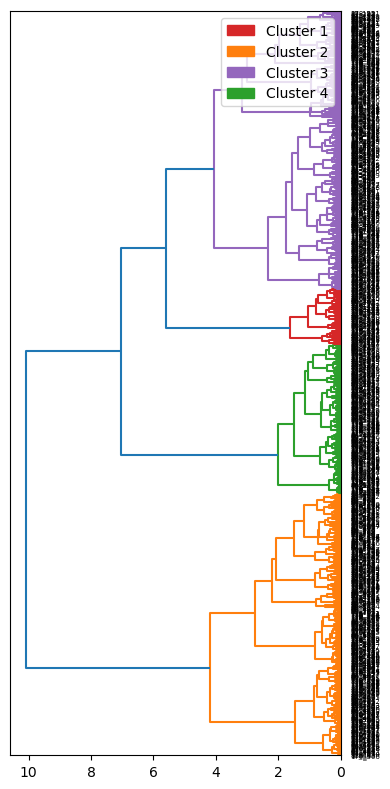

In [27]:
%matplotlib inline
import matplotlib.patches as mpatches


plt.figure(figsize=(4,8))

# dendrogram on the left
ddata = dendrogram(
    Z,
    labels=pt_caf_props.index,
    orientation="left",
    color_threshold=Z[-(4-1), 2]  # ensures 4 cluster colors
)

# extract the colors actually used by dendrogram
icoord = ddata['icoord']
dcoord = ddata['dcoord']
colors = ddata['color_list']

# matplotlib doesn’t automatically know "cluster 1 = color x"
# so we build a mapping manually:
unique_clusters = sorted(set(clusters))
unique_colors = list(set(colors))[:len(unique_clusters)]

# build legend handles
patches = [
    mpatches.Patch(color=unique_colors[i], label=f"Cluster {unique_clusters[i]}")
    for i in range(len(unique_clusters))
]

plt.legend(handles=patches, loc="upper right")
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


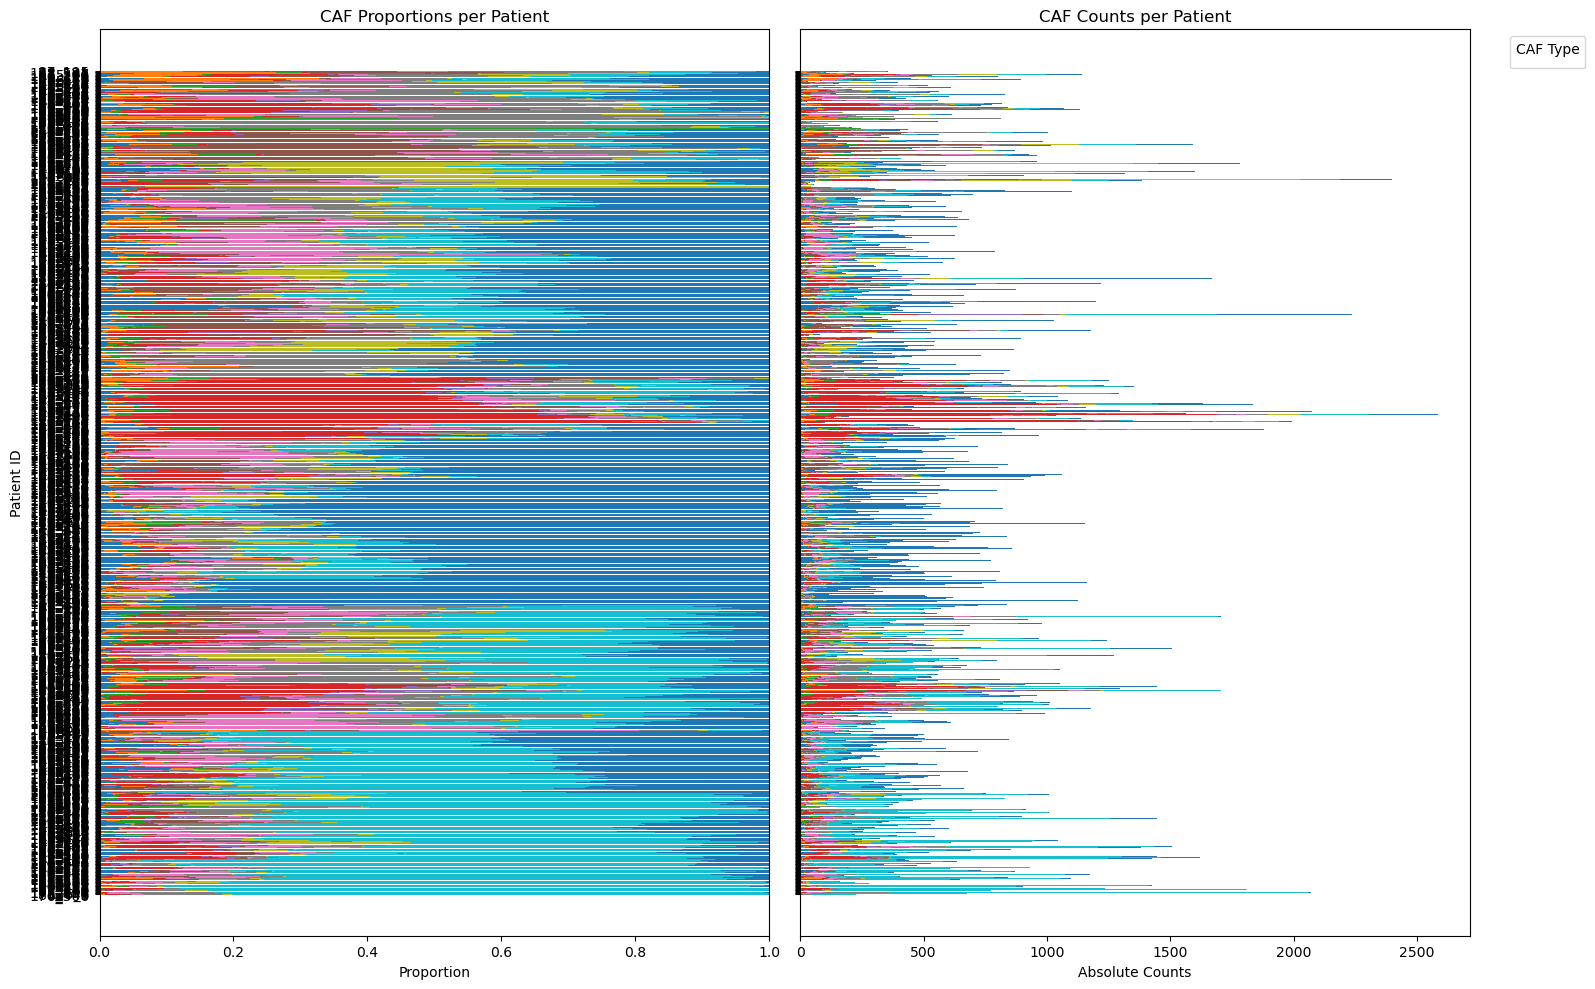

In [28]:
%matplotlib inline
caf_palette = sns.color_palette("tab10", n_colors=len(caf_cols_plotting))

# ----------------
# plotting
# ----------------
# fig, axes = plt.subplots(1, 3, figsize=(18, 12),
#                          gridspec_kw={"width_ratios":[0.5, 6, 6]},
#                          sharey=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharey=True)



# # dendrogram on the left
# ddata = dendrogram(
#     Z,
#     labels=pt_caf_props.index,
#     orientation="left",
#     color_threshold=Z[-(4-1), 2],  # ensures 4 cluster colors
#     ax=axes[0]
# )

# axes[0].set_yticks([])   # remove duplicated labels
# axes[0].set_xticks([])
# axes[0].set_title("Dendrogram")

# proportions stacked bar
bottom = pd.Series([0]*len(pt_caf_props_ordered), index=pt_caf_props_ordered.index)
for col, color in zip(caf_cols_plotting, caf_palette):
    axes[0].barh(pt_caf_props_ordered.index, pt_caf_props_ordered[col],
                 left=bottom, color=color, label=None)
    bottom += pt_caf_props_ordered[col]

axes[0].set_title("CAF Proportions per Patient")
axes[0].set_xlabel("Proportion")
axes[0].set_ylabel("Patient ID")

# # absolute counts stacked bar
bottom = pd.Series([0]*len(pt_caf_counts_oredered), index=pt_caf_counts_oredered.index)
for col, color in zip(caf_cols_plotting, caf_palette):
    axes[1].barh(pt_caf_counts_oredered.index, pt_caf_counts_oredered[col],
                 left=bottom, color=color, label=None)
    bottom += pt_caf_counts_oredered[col]

axes[1].set_title("CAF Counts per Patient")
axes[1].set_xlabel("Absolute Counts")
axes[1].set_ylabel("")

# add legend
axes[1].legend(title="CAF Type", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()


In [29]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.cluster.hierarchy import dendrogram
# import pandas as pd
# import numpy as np

# %matplotlib inline
# caf_palette = sns.color_palette("tab10", n_colors=len(caf_cols_plotting))

# # ----------------
# # plotting
# # ----------------
# fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# # Method 1: Use a custom ordering for dendrogram
# # If you have a specific order you want to maintain (e.g., ordered_idx)
# desired_order = ordered_idx  # or whatever order you prefer

# # Create dendrogram with no_plot=True first to get structure
# ddata_temp = dendrogram(Z, labels=pt_caf_props.index, orientation="left", no_plot=True)

# # Create dendrogram with your desired label order
# ddata = dendrogram(
#     Z,
#     labels=desired_order,  # Use your predetermined order
#     orientation="left",
#     color_threshold=Z[-(4-1), 2],
#     ax=axes[0]
# )

# # Use the same order for proportions
# pt_caf_props_ordered = pt_caf_props.loc[desired_order]

# # Stacked bar plot
# bottom = pd.Series([0]*len(pt_caf_props_ordered), index=range(len(desired_order)))
# for col, color in zip(caf_cols_plotting, caf_palette):
#     axes[1].barh(range(len(desired_order)), pt_caf_props_ordered[col],
#                  left=bottom, color=color, label=col)
#     bottom += pt_caf_props_ordered[col]

# axes[1].set_title("CAF Proportions per Patient")
# axes[1].set_xlabel("Proportion")
# axes[1].set_ylabel("Patient ID")

# # Ensure both axes have same y-ticks
# y_positions = range(len(desired_order))
# axes[0].set_yticks(y_positions)
# axes[0].set_yticklabels(desired_order)
# axes[1].set_yticks(y_positions)
# axes[1].set_yticklabels(desired_order)

# # Make sure y-axes are aligned
# axes[0].set_ylim(-0.5, len(desired_order)-0.5)
# axes[1].set_ylim(-0.5, len(desired_order)-0.5)

# axes[1].legend(title="CAF Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.tight_layout()
# plt.show()

In [30]:
# %matplotlib inline
# # palette for CAF types
# caf_palette = sns.color_palette("tab10", n_colors=len(caf_cols_plotting))

# # --- plotting ---
# fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharey=True)

# # proportions stacked bar
# bottom = pd.Series([0]*len(pt_caf_props), index=pt_caf_props.index)
# for col, color in zip(caf_cols_plotting, caf_palette):
#     axes[0].barh(pt_caf_props.index, pt_caf_props[col],
#                  left=bottom, color=color, label=col)
#     bottom += pt_caf_props[col]

# axes[0].set_title("CAF Proportions per Patient")
# axes[0].set_xlabel("Proportion")
# axes[0].set_ylabel("Patient ID")

# # absolute counts stacked bar
# bottom = pd.Series([0]*len(pt_caf_counts), index=pt_caf_counts.index)
# for col, color in zip(caf_cols_plotting, caf_palette):
#     axes[1].barh(pt_caf_counts.index, pt_caf_counts[col],
#                  left=bottom, color=color, label=col)
#     bottom += pt_caf_counts[col]

# axes[1].set_title("CAF Counts per Patient")
# axes[1].set_xlabel("Absolute Counts")
# axes[1].set_ylabel("")

# # legend once, outside
# axes[1].legend(title="CAF Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.tight_layout()
# plt.show()


## survival from pt cluster

In [31]:
clusters_df = pd.DataFrame(pt_cluster_ordered, columns=["cluster"])
clusters_df = clusters_df.reset_index()
clusters_df

,pt_id,cluster
0,176_306,1
1,88_443,1
2,175_8,1
3,178_490,1
4,175_174,1
...,...,...
1048,87_219,4
1049,175_93,4
1050,87_247,4
1051,178_521,4


In [32]:
# add the clinical data
pt_clinical_data = pd.read_csv('/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/clinical_data_ROI.csv')

# # remove NA and neoadjuvant therapy
# pt_clinical_data = pt_clinical_data[~pt_clinical_data['NeoAdj'].isna()]
# pt_clinical_data = pt_clinical_data[pt_clinical_data['NeoAdj']!='NeoAdjuvantTherapy'].reset_index(drop=True) # exclude NeoAdjuvantTherapy, see original paper
pt_clinical_data = pt_clinical_data[['Patient_ID', 'OS', 'DFS', 'Ev.O']]

# # remove duplicates after subsetting for pt and survival info
pt_clinical_data = pt_clinical_data.drop_duplicates(keep='first').reset_index(drop=True)
pt_clinical_data


,Patient_ID,OS,DFS,Ev.O
0,175_1,254.0,NaN,1.0
1,175_5,3420.0,3420.0,1.0
2,175_9,1312.0,1312.0,1.0
3,175_13,1950.0,1950.0,1.0
4,175_21,820.0,820.0,1.0
...,...,...,...,...
1066,88_521,596.0,370.0,1.0
1067,88_525,323.0,323.0,1.0
1068,88_529,1707.0,1707.0,0.0
1069,88_533,1652.0,1652.0,0.0


In [33]:
pt_cluster_survival = clusters_df.merge(pt_clinical_data, how='left', left_on='pt_id', right_on='Patient_ID')

# exclude pt where OS, outcome is unavailable
pt_cluster_survival = pt_cluster_survival[~pt_cluster_survival['OS'].isna()].reset_index(drop=True)
pt_cluster_survival = pt_cluster_survival[~(pt_cluster_survival['OS']==0)].reset_index(drop=True)

pt_cluster_survival = pt_cluster_survival[~pt_cluster_survival['Ev.O'].isna()].reset_index(drop=True)
print("number of unique patients:", pt_cluster_survival['Patient_ID'].nunique())
print(np.unique(pt_cluster_survival['Ev.O'], return_counts=True))

pt_cluster_survival

number of unique patients: 1043
(array([0., 1.]), array([324, 719]))


,pt_id,cluster,Patient_ID,OS,DFS,Ev.O
0,176_306,1,176_306,1623.0,547.0,1.0
1,88_443,1,88_443,2128.0,148.0,0.0
2,175_8,1,175_8,513.0,342.0,1.0
3,178_490,1,178_490,267.0,140.0,1.0
4,175_174,1,175_174,3609.0,3609.0,0.0
...,...,...,...,...,...,...
1038,87_219,4,87_219,3588.0,3588.0,1.0
1039,175_93,4,175_93,525.0,525.0,1.0
1040,87_247,4,87_247,1859.0,937.0,1.0
1041,178_521,4,178_521,1867.0,1867.0,0.0


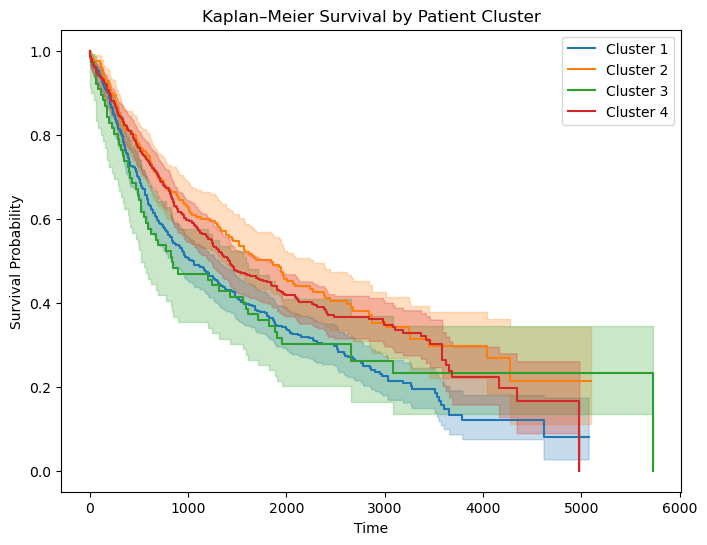

In [34]:
%matplotlib inline

# survival analysis after clustering

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Suppose you have survival_time and event columns for each patient
survival_time = pt_cluster_survival["OS"]  # replace with your variable
event = pt_cluster_survival["Ev.O"]         # 1 = event occurred, 0 = censored

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))
for i in sorted(pt_cluster_survival['cluster'].unique()):
    mask = pt_cluster_survival['cluster'] == i
    kmf.fit(survival_time[mask], event[mask], label=f"Cluster {i}")
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Survival by Patient Cluster")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

In [35]:
from lifelines.statistics import multivariate_logrank_test

# survival_time: time to event (array-like)
# event: event indicator (1 = event, 0 = censored)
# groups: cluster labels (1–4)

results = multivariate_logrank_test(
    survival_time,
    groups=pt_cluster_survival['cluster'],
    event_observed=event
)

print("Global log-rank test p-value:", results.p_value)

# Example log-rank test between clusters 1 and 2
results = logrank_test(
    survival_time[pt_cluster_survival['cluster']==1], 
    survival_time[pt_cluster_survival['cluster']==2],
    event[pt_cluster_survival['cluster']==1], 
    event[pt_cluster_survival['cluster']==2]
)
print("Log-rank p-value:", results.p_value)

results = logrank_test(
    survival_time[pt_cluster_survival['cluster']==2], 
    survival_time[pt_cluster_survival['cluster']==3],
    event[pt_cluster_survival['cluster']==2], 
    event[pt_cluster_survival['cluster']==3]
)
print("Log-rank p-value:", results.p_value)

results = logrank_test(
    survival_time[pt_cluster_survival['cluster']==1], 
    survival_time[pt_cluster_survival['cluster']==3],
    event[pt_cluster_survival['cluster']==1], 
    event[pt_cluster_survival['cluster']==3]
)
print("Log-rank p-value:", results.p_value)

Global log-rank test p-value: 0.0007011210138622949
Log-rank p-value: 0.0005612273325048153
Log-rank p-value: 0.030698746670642152
Log-rank p-value: 0.9196169768271434


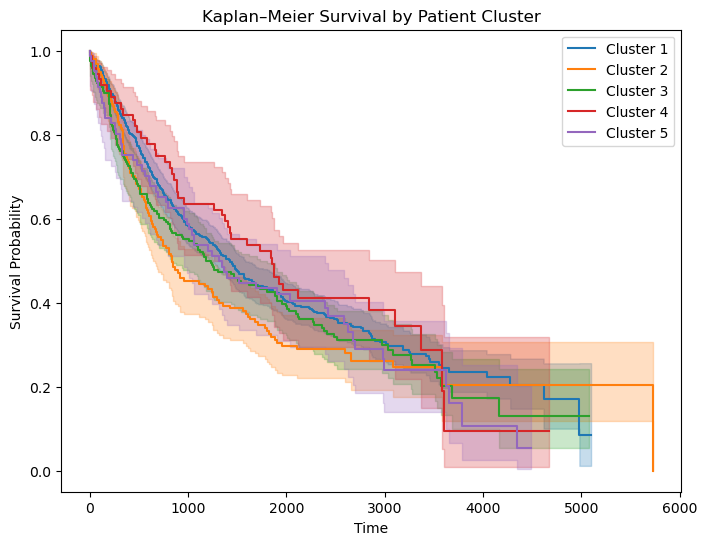

In [30]:
%matplotlib inline

# survival analysis after clustering

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Suppose you have survival_time and event columns for each patient
survival_time = pt_cluster_survival["OS"]  # replace with your variable
event = pt_cluster_survival["Ev.O"]         # 1 = event occurred, 0 = censored

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))
for i in sorted(pt_cluster_survival['cluster'].unique()):
    mask = pt_cluster_survival['cluster'] == i
    kmf.fit(survival_time[mask], event[mask], label=f"Cluster {i}")
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Survival by Patient Cluster")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

In [31]:
from lifelines.statistics import multivariate_logrank_test

# survival_time: time to event (array-like)
# event: event indicator (1 = event, 0 = censored)
# groups: cluster labels (1–4)

results = multivariate_logrank_test(
    survival_time,
    groups=pt_cluster_survival['cluster'],
    event_observed=event
)

print("Global log-rank test p-value:", results.p_value)

# Example log-rank test between clusters 1 and 2
results = logrank_test(
    survival_time[pt_cluster_survival['cluster']==1], 
    survival_time[pt_cluster_survival['cluster']==2],
    event[pt_cluster_survival['cluster']==1], 
    event[pt_cluster_survival['cluster']==2]
)
print("Log-rank p-value:", results.p_value)

results = logrank_test(
    survival_time[pt_cluster_survival['cluster']==2], 
    survival_time[pt_cluster_survival['cluster']==3],
    event[pt_cluster_survival['cluster']==2], 
    event[pt_cluster_survival['cluster']==3]
)
print("Log-rank p-value:", results.p_value)

results = logrank_test(
    survival_time[pt_cluster_survival['cluster']==1], 
    survival_time[pt_cluster_survival['cluster']==3],
    event[pt_cluster_survival['cluster']==1], 
    event[pt_cluster_survival['cluster']==3]
)
print("Log-rank p-value:", results.p_value)

Global log-rank test p-value: 0.16020090753617258
Log-rank p-value: 0.03308055218125083
Log-rank p-value: 0.4516299404232895
Log-rank p-value: 0.22033927414174018


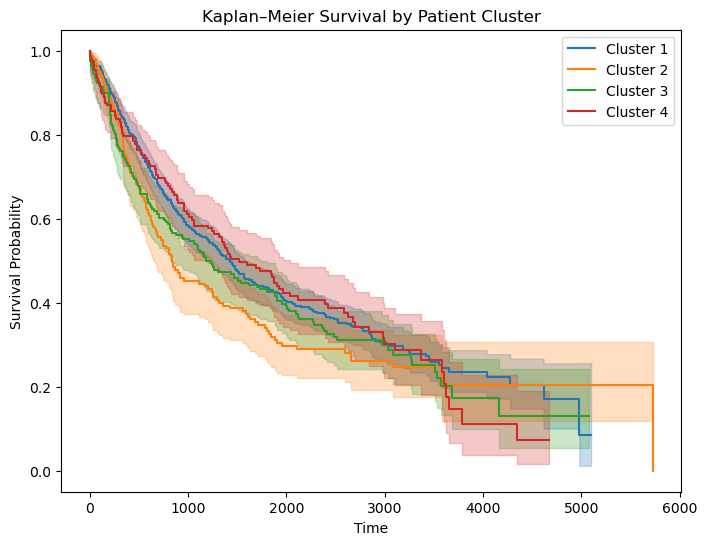

In [ ]:
%matplotlib inline

# survival analysis after clustering

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Suppose you have survival_time and event columns for each patient
survival_time = pt_cluster_survival["OS"]  # replace with your variable
event = pt_cluster_survival["Ev.O"]         # 1 = event occurred, 0 = censored

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))
for i in sorted(pt_cluster_survival['cluster'].unique()):
    mask = pt_cluster_survival['cluster'] == i
    kmf.fit(survival_time[mask], event[mask], label=f"Cluster {i}")
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Survival by Patient Cluster")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

In [79]:
from lifelines.statistics import multivariate_logrank_test

# survival_time: time to event (array-like)
# event: event indicator (1 = event, 0 = censored)
# groups: cluster labels (1–4)

results = multivariate_logrank_test(
    survival_time,
    groups=pt_cluster_survival['cluster'],
    event_observed=event
)

print("Global log-rank test p-value:", results.p_value)


Global log-rank test p-value: 0.15027254565602205


In [81]:
# Example log-rank test between clusters 1 and 2
results = logrank_test(
    survival_time[pt_cluster_survival['cluster']==4], 
    survival_time[pt_cluster_survival['cluster']==2],
    event[pt_cluster_survival['cluster']==4], 
    event[pt_cluster_survival['cluster']==2]
)
print("Log-rank p-value:", results.p_value)

Log-rank p-value: 0.10211904242464047


In [80]:
# Example log-rank test between clusters 1 and 2
results = logrank_test(
    survival_time[pt_cluster_survival['cluster']==3], 
    survival_time[pt_cluster_survival['cluster']==2],
    event[pt_cluster_survival['cluster']==3], 
    event[pt_cluster_survival['cluster']==2]
)
print("Log-rank p-value:", results.p_value)

Log-rank p-value: 0.4516299404232904


## survival by median proportions

In [41]:
pt_props_survival = pt_cluster_survival.merge(pt_caf_props_ordered.reset_index(), how='left')
pt_props_survival

,pt_id,cluster,Patient_ID,OS,DFS,Ev.O,mCAF,iCAF,tCAF,hypoxic CAF,hypoxic tCAF,IFN CAF,vCAF,dCAF,PDPN CAF,Collagen CAF,SMA CAF
0,176_306,1,176_306,1623.0,547.0,1.0,0.000000,0.008772,0.000000,0.021930,0.000000,0.017544,0.017544,0.118421,0.013158,0.802632,0.000000
1,88_443,1,88_443,2128.0,148.0,0.0,0.000000,0.001481,0.005926,0.000000,0.001481,0.002963,0.050370,0.120000,0.000000,0.816296,0.001481
2,175_8,1,175_8,513.0,342.0,1.0,0.000966,0.000483,0.002899,0.007246,0.001932,0.000483,0.031401,0.127536,0.000483,0.820773,0.005797
3,178_490,1,178_490,267.0,140.0,1.0,0.000000,0.002857,0.002857,0.005714,0.000000,0.002857,0.037143,0.117143,0.005714,0.825714,0.000000
4,175_174,1,175_174,3609.0,3609.0,0.0,0.000000,0.006061,0.000000,0.000000,0.000000,0.048485,0.030303,0.072727,0.000000,0.830303,0.012121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,87_219,4,87_219,3588.0,3588.0,1.0,0.033084,0.081110,0.010672,0.165422,0.069370,0.014941,0.100320,0.198506,0.000000,0.160085,0.166489
1039,175_93,4,175_93,525.0,525.0,1.0,0.050926,0.263889,0.171296,0.009259,0.004630,0.064815,0.004630,0.129630,0.212963,0.041667,0.046296
1040,87_247,4,87_247,1859.0,937.0,1.0,0.000000,0.264151,0.037736,0.009434,0.000000,0.292453,0.000000,0.198113,0.018868,0.094340,0.084906
1041,178_521,4,178_521,1867.0,1867.0,0.0,0.000000,0.124294,0.121469,0.008475,0.002825,0.186441,0.076271,0.262712,0.000000,0.197740,0.019774


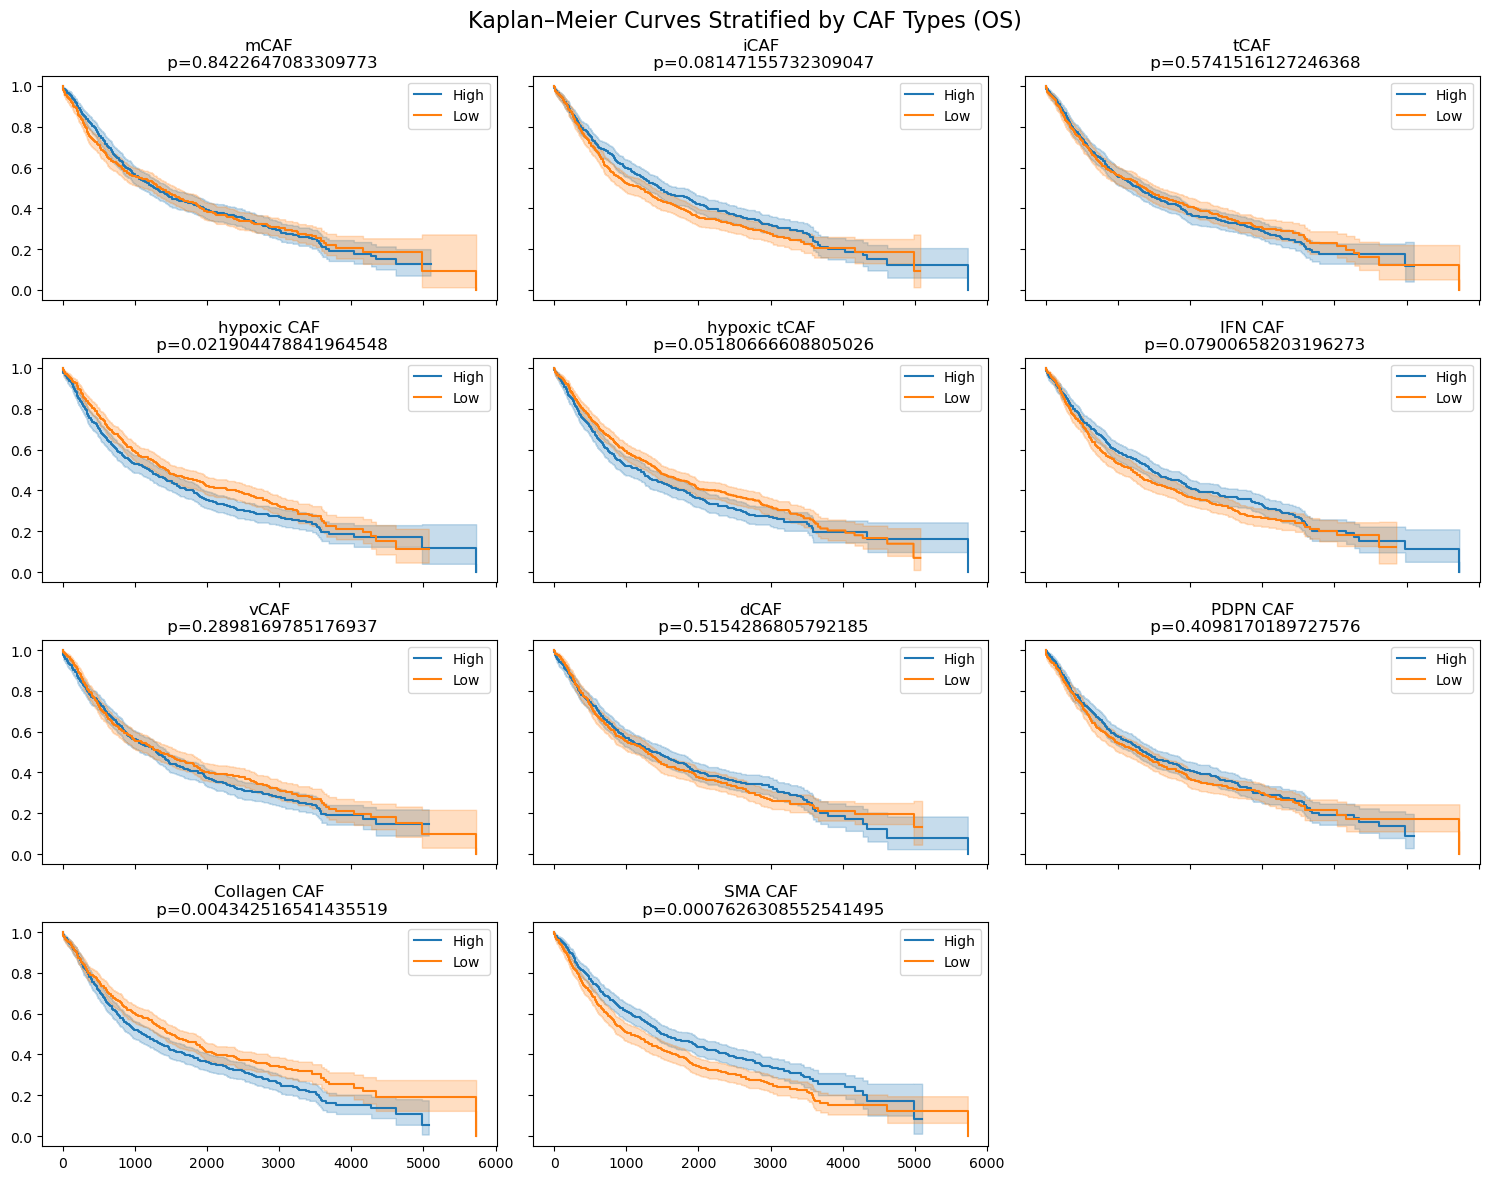

In [43]:
# Assume df is your dataframe
time_col = "OS"       # survival time (Overall Survival)
event_col = "Ev.O"    # event indicator (1=death, 0=censored)

caf_cols = ["mCAF", "iCAF", "tCAF", "hypoxic CAF", "hypoxic tCAF",
            "IFN CAF", "vCAF", "dCAF", "PDPN CAF", "Collagen CAF", "SMA CAF"]

kmf = KaplanMeierFitter()

# Create subplots (e.g., 3x4 grid to fit 11 CAF types)
n_cols = 3
n_rows = (len(caf_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12), sharex=True, sharey=True)

for i, caf in enumerate(caf_cols):
    ax = axes[i // n_cols, i % n_cols]
    
    # split into high/low groups by median
    median_val = pt_props_survival[caf].median()
    pt_props_survival["CAF_group"] = (pt_props_survival[caf] > median_val).map({True: "High", False: "Low"})
    
    # survival groups
    high = pt_props_survival[pt_props_survival["CAF_group"] == "High"]
    low = pt_props_survival[pt_props_survival["CAF_group"] == "Low"]

    # Kaplan–Meier fit
    kmf.fit(high[time_col], event_observed=high[event_col], label="High")
    kmf.plot_survival_function(ax=ax, ci_show=True)
    
    kmf.fit(low[time_col], event_observed=low[event_col], label="Low")
    kmf.plot_survival_function(ax=ax, ci_show=True)
    
    # log-rank test
    results = logrank_test(high[time_col], low[time_col],
                           event_observed_A=high[event_col],
                           event_observed_B=low[event_col])
    p_value = results.p_value
    
    # title and annotate p-value
    ax.set_title(f"{caf}\n p={p_value}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.legend()

# Hide empty subplots
for j in range(i+1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])

fig.suptitle("Kaplan–Meier Curves Stratified by CAF Types (OS)", fontsize=16)
plt.tight_layout()
plt.show()

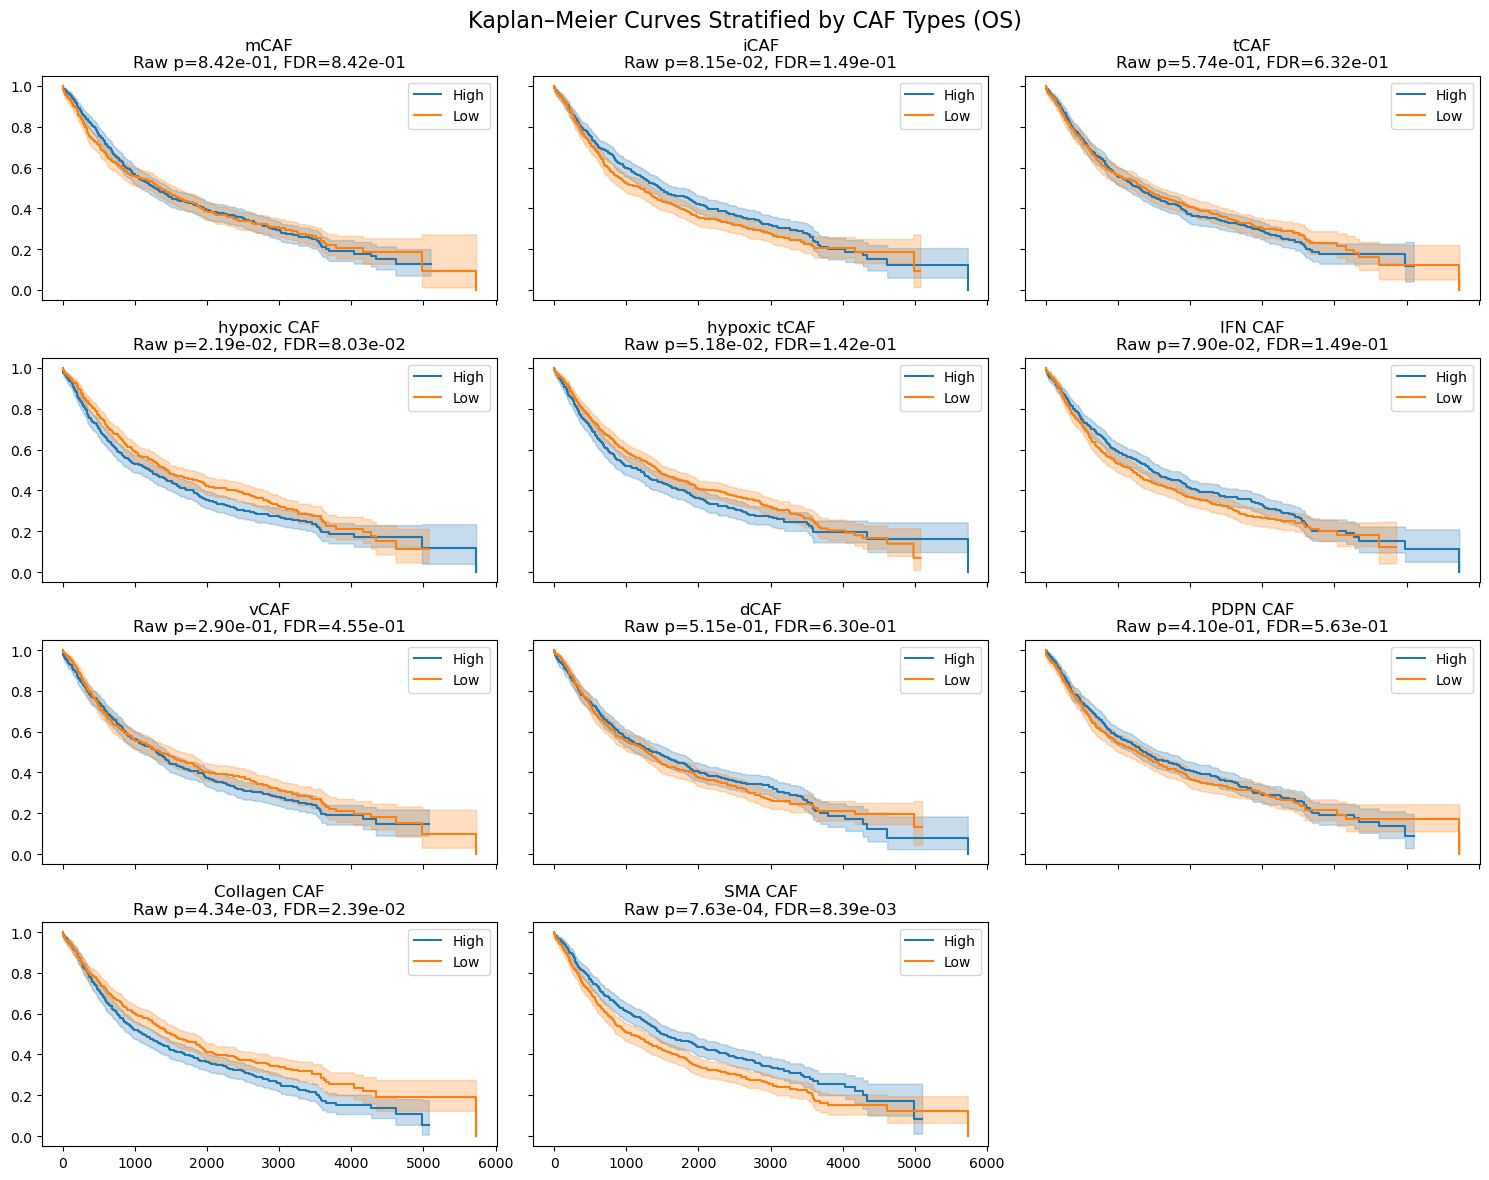

In [45]:
from statsmodels.stats.multitest import multipletests

# --- Step 1: compute raw p-values for all CAFs ---
pvals = []
for caf in caf_cols:
    median_val = pt_props_survival[caf].median()
    pt_props_survival["CAF_group"] = (pt_props_survival[caf] > median_val).map({True: "High", False: "Low"})
    
    high = pt_props_survival[pt_props_survival["CAF_group"] == "High"]
    low = pt_props_survival[pt_props_survival["CAF_group"] == "Low"]

    results = logrank_test(high[time_col], low[time_col],
                           event_observed_A=high[event_col],
                           event_observed_B=low[event_col])
    pvals.append(results.p_value)

# --- Step 2: FDR (Benjamini–Hochberg) correction ---
_, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

# --- Step 3: Plot Kaplan–Meier curves with both p-values ---
n_cols = 3
n_rows = (len(caf_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12), sharex=True, sharey=True)

for i, (caf, pval, pval_fdr) in enumerate(zip(caf_cols, pvals, pvals_fdr)):
    ax = axes[i // n_cols, i % n_cols]
    
    # stratify high/low by median
    median_val = pt_props_survival[caf].median()
    pt_props_survival["CAF_group"] = (pt_props_survival[caf] > median_val).map({True: "High", False: "Low"})
    
    high = pt_props_survival[pt_props_survival["CAF_group"] == "High"]
    low = pt_props_survival[pt_props_survival["CAF_group"] == "Low"]

    # Kaplan–Meier fit and plot
    kmf.fit(high[time_col], event_observed=high[event_col], label="High")
    kmf.plot_survival_function(ax=ax, ci_show=True)
    
    kmf.fit(low[time_col], event_observed=low[event_col], label="Low")
    kmf.plot_survival_function(ax=ax, ci_show=True)

    # Title with raw + FDR-adjusted p-value
    ax.set_title(f"{caf}\nRaw p={pval:.2e}, FDR={pval_fdr:.2e}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.legend()

# Hide unused axes
for j in range(i+1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])

fig.suptitle("Kaplan–Meier Curves Stratified by CAF Types (OS)", fontsize=16)
plt.tight_layout()
plt.show()

In [41]:
temp = non_tumor_cleaned[non_tumor_cleaned[cd4_marker] & non_tumor_cleaned[cd3_marker]]

temp = temp[[cd3_marker, foxp3_marker, "final_cell_type"]]

temp['final_cell_type'].isna()

3558        True
4723        True
4727       False
4730       False
4742       False
           ...  
2907926    False
2907944    False
2908107     True
2908189    False
2909204     True
Name: final_cell_type, Length: 4149, dtype: bool

In [42]:
non_tumor_cleaned['final_cell_type'].isna()

0          True
1          True
2          True
3          True
4          True
           ... 
2910066    True
2910067    True
2910068    True
2910069    True
2910070    True
Name: final_cell_type, Length: 2895173, dtype: bool

In [20]:
len(cd3_cd20_pos) / len(non_tumor_cells)
len(non_tumor_cells)

2910071

# scratch

In [45]:
all_tumor_cells = 0
all_nontumor_cells = 0
accumul_type = 'sum'

for prefix in SAVED_GROUPS:
    prefix_pt_roi_path = f'/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/nsclc_save_group{prefix}/nsclc_save_group{prefix}.pkl'
    cytof_cohort_whole_slide = pkl.load(open(prefix_pt_roi_path, 'rb'))
    pt_prefix_rois = roi_pt_id_mapping[roi_pt_id_mapping['ROI'].str.startswith(f'{prefix}_')].reset_index(drop=True)
    prefix_pt_ids = np.unique([pt_prefix_rois['Patient_ID']])
    print(f"\n{len(prefix_pt_ids)} unique patient IDs identified in 'nsclc_save_group{prefix}.pkl' file")

    prefix_pt_ids = prefix_pt_ids[:5]

    save_group_df_list = list()
    # process for each patient
    for pt_id in prefix_pt_ids:
        print('\nProcessing Patient ID', pt_id)
        per_pt_roi_dict = dict() # to be pass into CytofCohort later

        # load the pt's ROIs
        df_to_load = pt_prefix_rois[pt_prefix_rois['Patient_ID']==pt_id]
        print(len(df_to_load), 'ROIs identified for patient', pt_id)

        try:
            # load all of this pt's ROI into a new dict
            for index, row in df_to_load.iterrows():
                new_key = f"{row['SLIDE']}_{row['ROI']}"
                per_pt_roi_dict[new_key] = cytof_cohort_whole_slide.cytof_images[new_key]

            # df_cohort not saved, creating one automatically from CytofCohort
            per_pt_cohort = CytofCohort(cytof_images=per_pt_roi_dict, dir_out=None)
            per_pt_cohort.batch_process_feature()
            per_pt_cohort.generate_summary(accumul_type=accumul_type)
                
            # go through each roi, get their binary marker-cell expression
            for key, cytof_img in per_pt_cohort.cytof_images.items():
                
                # get the mean expression
                pt_binary_df = cytof_img.get_binary_pos_express_df(feature_name='75normed', accumul_type=accumul_type)
                
                save_binary_df = pt_binary_df.copy()
                save_binary_df['pt_id'] = pt_id
                save_binary_df['roi_id'] = key

                save_group_df_list.append(save_binary_df)
                
                panck_col = "panCyto_234((2745))Lu175-Lu175_cell_sum"

                # mean panCK expression used to identify tumor cells
                # then count number of cells with positively expressed panCK
                per_pt_tumor_cells = np.sum(pt_binary_df[panck_col])
                per_pt_nontumor_cells = len(pt_binary_df) - per_pt_tumor_cells

                # tally up
                all_tumor_cells += per_pt_tumor_cells
                all_nontumor_cells += per_pt_nontumor_cells


        except Exception as e:
            print(f'pt_id {pt_id} not processed due to error {e}')

    
    print("# of tumor cells so far:", all_tumor_cells)
    print("# of nontumor cells so far:", all_nontumor_cells)

    # concatenate to one df at the group level
    save_group_binary_df = pd.concat(save_group_df_list)

    # save to file
    save_path = os.path.join(BASE_PKL_DIR, f'nsclc_save_group{prefix}', f'XXXnsclc_save_group{prefix}_binary_expr_df_{accumul_type}.csv')
    save_group_binary_df.to_csv(save_path, index=False)
    
    


139 unique patient IDs identified in 'nsclc_save_group86.pkl' file

Processing Patient ID 86_1
2 ROIs identified for patient 86_1
Getting thresholds for cell sum of all markers.

Processing Patient ID 86_10
1 ROIs identified for patient 86_10
Getting thresholds for cell sum of all markers.

Processing Patient ID 86_100
2 ROIs identified for patient 86_100
Getting thresholds for cell sum of all markers.

Processing Patient ID 86_101
2 ROIs identified for patient 86_101
Getting thresholds for cell sum of all markers.

Processing Patient ID 86_102
2 ROIs identified for patient 86_102
Getting thresholds for cell sum of all markers.
# of tumor cells so far: 4963
# of nontumor cells so far: 10756

192 unique patient IDs identified in 'nsclc_save_group87.pkl' file

Processing Patient ID 87_162
2 ROIs identified for patient 87_162
Getting thresholds for cell sum of all markers.

Processing Patient ID 87_163
1 ROIs identified for patient 87_163
Getting thresholds for cell sum of all markers.



In [48]:
from datetime import datetime
current_datetime = datetime.now()
formatted_datetime = current_datetime.strftime("%Y-%m-%d %H:%M:%S")
formatted_datetime

print(formatted_datetime, f"file saved to {save_path}")

2025-08-20 17:07:03 file saved to /project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/nsclc_save_group87/XXXnsclc_save_group87_binary_expr_df_sum.csv


In [41]:
concatenated_df = pd.concat(save_group_df_list)
concatenated_df

,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,anti-Hu_1950((2832))Yb173-Yb173_cell_sum,CCL21 6_2177((2889))Yb174-Yb174_cell_sum,panCyto_234((2745))Lu175-Lu175_cell_sum,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id
0,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,87_162,NSCLC_ALL_87_A_A1_1
1,False,False,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,87_162,NSCLC_ALL_87_A_A1_1
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,87_162,NSCLC_ALL_87_A_A1_1
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,87_162,NSCLC_ALL_87_A_A1_1
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,87_162,NSCLC_ALL_87_A_A1_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2979,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,87_167,NSCLC_ALL_87_A_A4_2
2980,False,False,False,True,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,87_167,NSCLC_ALL_87_A_A4_2
2981,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,87_167,NSCLC_ALL_87_A_A4_2
2982,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,87_167,NSCLC_ALL_87_A_A4_2


In [43]:
# np.unique(concatenated_df['slide_roi'], return_counts=True)
np.unique(concatenated_df['roi_id'], return_counts=True)

(array(['NSCLC_ALL_87_A_A1_1', 'NSCLC_ALL_87_A_A1_2',
        'NSCLC_ALL_87_A_A2_1', 'NSCLC_ALL_87_A_A2_2',
        'NSCLC_ALL_87_A_A3_2', 'NSCLC_ALL_87_A_A4_1',
        'NSCLC_ALL_87_A_A4_2', 'NSCLC_ALL_87_A_A5_1',
        'NSCLC_ALL_87_A_A6_1'], dtype=object),
 array([ 499, 2080, 2131, 1882, 1742, 2487, 2984, 2398, 2095]))

In [19]:
df_to_load

,SLIDE,ROI,input file,save_group,roi_mappable,RoiID,Patient_ID,OS,DFS,Ev.O
0,NSCLC_ALL,88_B_B1_1,/project/Xie_Lab/zgu/xiao_multiplex/nsclc_tiff...,2,"88_B1,1","88_B1,1",88_422,898.0,586.0,1.0


In [10]:
rand_cytof_img.dict_feat

AttributeError: 'CytofImageTiff' object has no attribute 'dict_feat'

In [15]:
# store img into new dict
per_pt_roi_dict = {}
per_pt_roi_dict['temp'] = rand_cytof_img

per_pt_cohort = CytofCohort(cytof_images=per_pt_roi_dict, dir_out=None)
per_pt_cohort.batch_process_feature()
per_pt_cohort.generate_summary(accumul_type="ave")

Getting thresholds for cell ave of all markers.


['75normed_ave']

In [21]:
# df_feat = getattr(rand_cytof_img, 'df_feature_75normed')
# df_feat
df = rand_cytof_img.get_binary_pos_express_df(feature_name='75normed', accumul_type='ave')
df

,Myelope_276((2996))Y89-Y89_cell_ave,FSP1 S1_2263((3411))In113-In113_cell_ave,SMA_174((3277))In115-In115_cell_ave,117Sn-Sn117_cell_ave,Histone_126((2797))Pr141-Pr141_cell_ave,fap_323((3412))Nd142-Nd142_cell_ave,HLA-DR_1849((3362))Nd143-Nd143_cell_ave,CD146_22((3259))Nd144-Nd144_cell_ave,Cadheri_2088((2893))Nd145-Nd145_cell_ave,Carboni_2443((2757))Nd146-Nd146_cell_ave,...,CD4_2293((3000))Yb171-Yb171_cell_ave,CD31_1859((3370))Yb172-Yb172_cell_ave,anti-Hu_1950((2832))Yb173-Yb173_cell_ave,CCL21 6_2177((2889))Yb174-Yb174_cell_ave,panCyto_234((2745))Lu175-Lu175_cell_ave,K-Cadhe_2600((3417))Yb176-Yb176_cell_ave,Ki-67_142((3418))Pt194-Pt194_cell_ave,Caveoli_1945((2899))Pt195-Pt195_cell_ave,206Pb-Pb206_cell_ave,CD15_627((2997))Bi209-Bi209_cell_ave
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,True,False,False,False,True,False,False,...,False,True,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,False,False,True,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1071,False,False,False,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1072,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1073,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [23]:
panck_col = "panCyto_234((2745))Lu175-Lu175_cell_ave"
np.sum(df[panck_col])

195

In [25]:
len(df)

1075